In [1]:
# Cell 1 — Imports  (pyarrow MUST be first: Windows DLL fix)
import pyarrow
import transformers
import torch
import os, sys, math
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm

print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    free_gb, total_gb = torch.cuda.mem_get_info()
    print(f'VRAM: {free_gb/1e9:.1f} GB free / {total_gb/1e9:.1f} GB total')

torch 2.5.1+cu121 | CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 7.5 GB free / 8.6 GB total


In [2]:
# Cell 2 — Config
from dotenv import load_dotenv
load_dotenv('../.env')

MODEL_NAME       = 'meta-llama/Llama-3.1-8B-Instruct'
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES        = 200
NLDD_THRESHOLD   = 0.1
THRESHOLD_FACTOR = 0.5
N_BINS           = 10
OUT_DIR          = '../outputs'
DATASETS         = ['gsm8k', 'prontoqa']

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Model: {MODEL_NAME}  |  Device: {DEVICE}')
print(f'Samples: {N_SAMPLES}  |  NLDD threshold: {NLDD_THRESHOLD}')
print(f'Datasets: {DATASETS}')

Model: meta-llama/Llama-3.1-8B-Instruct  |  Device: cuda
Samples: 200  |  NLDD threshold: 0.1
Datasets: ['gsm8k', 'prontoqa']


In [3]:
# Cell 3 — Load LLaMA-3.1-8B via get_model (4-bit BnB quantization ~5 GB VRAM)
from src.utils.model_loader import get_model

print(f'Loading {MODEL_NAME} (4-bit quantized)...')
model = get_model(MODEL_NAME, device=DEVICE)
print(f'Loaded  layers={model.cfg.n_layers}  d_model={model.cfg.d_model}  vocab={model.cfg.d_vocab}')
if torch.cuda.is_available():
    free_b, total_b = torch.cuda.mem_get_info()
    print(f'VRAM used: {(total_b - free_b)/1e9:.1f} GB')

Loading meta-llama/Llama-3.1-8B-Instruct (4-bit quantized)...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded  layers=32  d_model=4096  vocab=128256
VRAM used: 7.0 GB


In [4]:
# Cell 4 — Load datasets
from data.dataset_loader import load_gsm8k, load_prontoqa

samples_by_dataset = {}
for ds_name in DATASETS:
    if ds_name == 'gsm8k':
        raw = load_gsm8k(split='test', max_samples=N_SAMPLES)
        samples_by_dataset['gsm8k'] = raw
        print(f'GSM8K: {len(raw)} samples')
        if raw:
            s0 = raw[0]
            print(f'  Example Q: {s0["question"][:80]}')
            print(f'  Steps ({len(s0["steps"])}): {s0["steps"][0][:60]}')
    elif ds_name == 'prontoqa':
        raw = load_prontoqa(split='train', max_samples=N_SAMPLES)
        for s in raw:
            s['steps'] = s.pop('chain', [])
        filtered = [s for s in raw if len(s['steps']) >= 2]
        samples_by_dataset['prontoqa'] = filtered
        print(f'PrOntoQA: {len(filtered)} samples ({len(raw)} loaded, '
              f'{len(raw) - len(filtered)} filtered)')
        if filtered:
            s0 = filtered[0]
            print(f'  Example Q: {s0["question"][:80]}')
            print(f'  Steps ({len(s0["steps"])}): {s0["steps"][0][:60]}')

GSM8K: 200 samples
  Example Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning an
  Steps (3): Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.


README.md:   0%|          | 0.00/558 [00:00<?, ?B/s]

C:\Users\gsr20\Desktop\COT-Align\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gsr20\.cache\huggingface\hub\datasets--fengyang0317--prontoqa. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/2.26M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/56.0k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/204k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/800 [00:00<?, ? examples/s]

PrOntoQA: 200 samples (200 loaded, 0 filtered)
  Example Q: Numpuses are not wooden. Vumpuses are lempuses. Rompuses are not dull. Each lorp
  Steps (6): Max is a vumpus. Each vumpus is a brimpus.


In [5]:
# Cell 5 — Define run_experiment_for_sample
from src.probing.faithfulness_detector import generate_faithfulness_labels, corrupt_step
from src.probing.cot_probe import extract_cot_activations
from src.utils.metrics import compute_all_metrics

def run_experiment_for_sample(sample, model, strategy='number_perturbation'):
    """NLDD + RSA + TAS analysis for one sample."""
    question, steps = sample['question'], sample['steps']
    if len(steps) < 2:
        return None
    prompt = 'Q: ' + question + ' A: ' + ' '.join(steps)
    try:
        labels = generate_faithfulness_labels(
            model, prompt, steps,
            strategy=strategy, nldd_threshold=NLDD_THRESHOLD)
    except Exception as exc:
        print(f'  skip ({type(exc).__name__})')
        return None
    nldd_scores = [nldd for _, _, nldd in labels]
    clean_acts = extract_cot_activations(model, prompt)
    c0       = corrupt_step(steps[0], strategy=strategy, seed=0)
    c_prompt = prompt.replace(steps[0], c0, 1)
    c_acts   = extract_cot_activations(model, c_prompt)
    with torch.no_grad():
        lp_c = float(torch.log_softmax(model(model.to_tokens(prompt))[0, -1], dim=-1).max())
        lp_r = float(torch.log_softmax(model(model.to_tokens(c_prompt))[0, -1], dim=-1).max())
    metrics = compute_all_metrics(clean_acts, c_acts, lp_c, lp_r)
    return {'nldd_scores': nldd_scores, 'rsa': metrics['rsa'],
            'tas': metrics['tas'], 'n_steps': len(steps)}

print('run_experiment_for_sample defined.')

run_experiment_for_sample defined.

In [6]:
# Cell 6 — Run batch experiment per dataset
DATASET_STRATEGIES = {'gsm8k': 'number_perturbation', 'prontoqa': 'negate'}

results_by_dataset = {}
for ds_name in DATASETS:
    strategy = DATASET_STRATEGIES.get(ds_name, 'number_perturbation')
    samples  = samples_by_dataset.get(ds_name, [])
    results, n_skip = [], 0
    for sample in tqdm(samples, desc=f'Analysing {ds_name}'):
        r = run_experiment_for_sample(sample, model, strategy=strategy)
        if r is not None:
            results.append(r)
        else:
            n_skip += 1
    results_by_dataset[ds_name] = results
    print(f'{ds_name}: valid={len(results)}/{len(samples)}  skipped={n_skip}')
    if results:
        sc = [r['n_steps'] for r in results]
        print(f'  Steps/sample — min:{min(sc)}  max:{max(sc)}  mean:{np.mean(sc):.1f}')

Analysing gsm8k:   0%|          | 0/200 [00:00<?, ?it/s]

Analysing gsm8k:   0%|          | 1/200 [00:03<11:12,  3.38s/it]

Analysing gsm8k:   1%|          | 2/200 [00:05<09:12,  2.79s/it]

Analysing gsm8k:   2%|▏         | 3/200 [00:09<10:00,  3.05s/it]

Analysing gsm8k:   2%|▏         | 4/200 [00:11<09:05,  2.78s/it]

...

Analysing prontoqa:  99%|█████████▉| 198/200 [15:09<00:09,  4.60s/it]

Analysing prontoqa: 100%|█████████▉| 199/200 [15:13<00:04,  4.59s/it]

Analysing prontoqa: 100%|██████████| 200/200 [15:18<00:00,  4.59s/it]

Analysing prontoqa: 100%|██████████| 200/200 [15:18<00:00,  4.59s/it]

prontoqa: valid=200/200  skipped=0
  Steps/sample — min:6  max:6  mean:6.0


In [7]:
# Cell 7 — Normalise NLDD per dataset and compute k*
from src.pipeline.closed_loop import find_reasoning_horizon

DS_COLORS = {'gsm8k': 'steelblue', 'prontoqa': 'mediumpurple'}
DS_LABELS = {'gsm8k': 'GSM8K',     'prontoqa': 'PrOntoQA'}

normalised_data = {}
for ds_name, results in results_by_dataset.items():
    if not results:
        print(f'{ds_name}: no results, skipping.')
        continue
    norm_nldd = np.zeros((len(results), N_BINS))
    k_stars   = []
    for i, r in enumerate(results):
        scores = np.array(r['nldd_scores'], dtype=float)
        n      = len(scores)
        x_orig = np.linspace(0, 1, max(n, 2))
        x_new  = np.linspace(0, 1, N_BINS)
        padded = np.pad(scores, (0, max(0, 2 - n)), 'edge')
        norm_nldd[i] = np.interp(x_new, x_orig, padded)
        k = find_reasoning_horizon(r['nldd_scores'], threshold_factor=THRESHOLD_FACTOR)
        k_stars.append(k / max(1, n - 1))
    rsa_by_layer = {}
    for r in results:
        for l, v in r['rsa'].items():
            rsa_by_layer.setdefault(l, []).append(v)
    layers   = sorted(rsa_by_layer)
    rsa_mean = [np.mean(rsa_by_layer[l]) for l in layers]
    rsa_std  = [np.std(rsa_by_layer[l])  for l in layers]
    tas_vals = [r['tas'] for r in results if not math.isnan(r['tas'])]
    mu_tas   = float(np.mean(tas_vals)) if tas_vals else 0.0
    mean_k_star = float(np.mean(k_stars))
    normalised_data[ds_name] = dict(
        mean_nldd=norm_nldd.mean(axis=0), std_nldd=norm_nldd.std(axis=0),
        mean_k_star=mean_k_star, layers=layers,
        rsa_mean=rsa_mean, rsa_std=rsa_std,
        tas_vals=tas_vals, mu_tas=mu_tas,
    )
    all_nldd = [s for r in results for s in r['nldd_scores']]
    print(f'{DS_LABELS[ds_name]}: mean k*={mean_k_star:.3f}  '
          f'mean NLDD={np.mean(all_nldd):.4f}  n_steps={len(all_nldd)}')

GSM8K: mean k*=0.240  mean NLDD=0.0809  n_steps=897
PrOntoQA: mean k*=0.201  mean NLDD=-0.0505  n_steps=1200


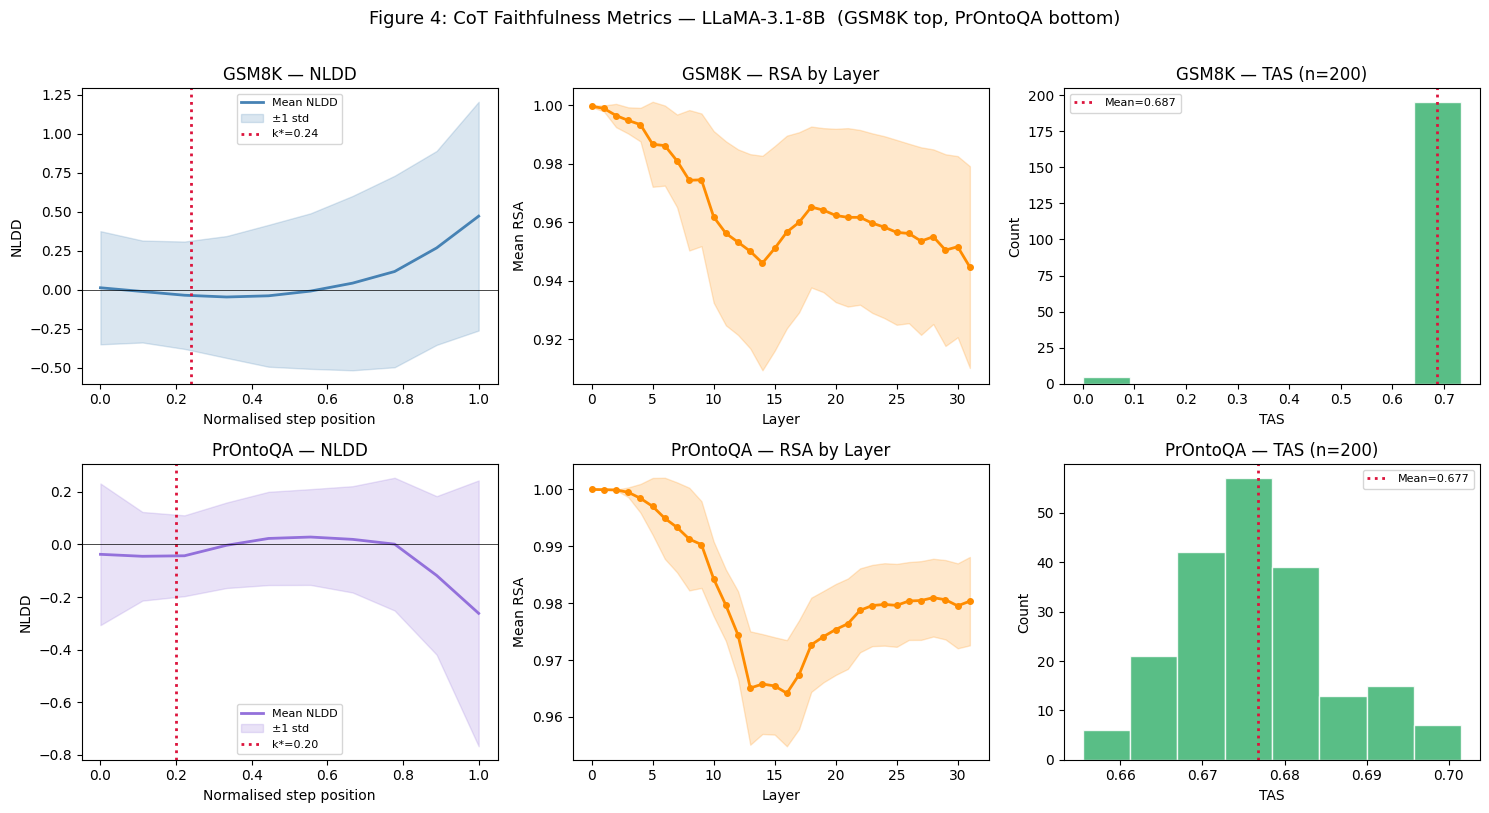

Saved -> outputs/figure4_llama_baseline.png


In [8]:
# Cell 8 — Figure 4: 2×3 subplots (GSM8K top row, PrOntoQA bottom row)
x_bins = np.linspace(0, 1, N_BINS)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, ds_name in enumerate(DATASETS):
    lbl = DS_LABELS.get(ds_name, ds_name)
    col = DS_COLORS.get(ds_name, 'steelblue')
    if ds_name not in normalised_data:
        for c in range(3):
            axes[row][c].text(0.5, 0.5, f'No data: {lbl}',
                ha='center', va='center', transform=axes[row][c].transAxes)
        continue
    d = normalised_data[ds_name]

    ax = axes[row][0]
    ax.plot(x_bins, d['mean_nldd'], color=col, lw=2, label='Mean NLDD')
    ax.fill_between(x_bins, d['mean_nldd'] - d['std_nldd'], d['mean_nldd'] + d['std_nldd'],
                    color=col, alpha=0.2, label='±1 std')
    ax.axvline(d['mean_k_star'], color='crimson', ls=':', lw=2,
               label=f"k*={d['mean_k_star']:.2f}")
    ax.axhline(0, color='black', lw=0.5)
    ax.set(xlabel='Normalised step position', ylabel='NLDD',
           title=f'{lbl} — NLDD')
    ax.legend(fontsize=8)

    ax = axes[row][1]
    ax.plot(d['layers'], d['rsa_mean'], color='darkorange', lw=2, marker='o', ms=4)
    ax.fill_between(d['layers'],
                    [m - s for m, s in zip(d['rsa_mean'], d['rsa_std'])],
                    [m + s for m, s in zip(d['rsa_mean'], d['rsa_std'])],
                    color='darkorange', alpha=0.2)
    ax.set(xlabel='Layer', ylabel='Mean RSA', title=f'{lbl} — RSA by Layer')

    ax = axes[row][2]
    ax.hist(d['tas_vals'], bins=8, color='mediumseagreen', edgecolor='white', alpha=0.85)
    ax.axvline(d['mu_tas'], color='crimson', ls=':', lw=2,
               label=f"Mean={d['mu_tas']:.3f}")
    ax.set(xlabel='TAS', ylabel='Count',
           title=f'{lbl} — TAS (n={len(d["tas_vals"])})')
    ax.legend(fontsize=8)

fig.suptitle('Figure 4: CoT Faithfulness Metrics — LLaMA-3.1-8B  (GSM8K top, PrOntoQA bottom)',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'figure4_llama_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/figure4_llama_baseline.png')

In [9]:
# Cell 9 — Observation table with one column per dataset
metric_labels = [
    'Mean NLDD (all steps)',
    'Mean NLDD (faithful steps)',
    'Mean NLDD (unfaithful steps)',
    'Faithful step fraction',
    'Mean RSA (all layers)',
    'Mean TAS',
    'Mean k* (normalised)',
    'Total steps analysed',
]

col_data = {'Metric': metric_labels}
for ds_name in DATASETS:
    results  = results_by_dataset.get(ds_name, [])
    d        = normalised_data.get(ds_name, {})
    all_nldd = [s for r in results for s in r['nldd_scores']]
    faith    = [s for s in all_nldd if s >  NLDD_THRESHOLD]
    unfai    = [s for s in all_nldd if s <= NLDD_THRESHOLD]
    col_data[DS_LABELS.get(ds_name, ds_name)] = [
        f'{np.mean(all_nldd):.4f}'           if all_nldd           else 'n/a',
        f'{np.mean(faith):.4f}'              if faith               else 'n/a',
        f'{np.mean(unfai):.4f}'              if unfai               else 'n/a',
        f'{len(faith)/max(1,len(all_nldd)):.1%}',
        f'{np.mean(d["rsa_mean"]):.4f}'      if d.get('rsa_mean')  else 'n/a',
        f'{d["mu_tas"]:.4f}'                 if d                   else 'n/a',
        f'{d["mean_k_star"]:.3f}'            if d                   else 'n/a',
        str(len(all_nldd)),
    ]

obs = pd.DataFrame(col_data)
print(obs.to_string(index=False))

                      Metric   GSM8K PrOntoQA
       Mean NLDD (all steps)  0.0809  -0.0505
  Mean NLDD (faithful steps)  0.5766   0.2301
Mean NLDD (unfaithful steps) -0.2687  -0.1708
      Faithful step fraction   41.4%    30.0%
       Mean RSA (all layers)  0.9663   0.9822
                    Mean TAS  0.6873   0.6768
        Mean k* (normalised)   0.240    0.201
        Total steps analysed     897     1200


In [10]:
# Cell 10
print('Notebook 04 complete')

Notebook 04 complete
